# 🛒 E-Commerce Churn Prediction Model

## Project Overview
This project builds a **machine learning model** to predict which customers are likely to churn (stop buying). We use **RFM analysis** (Recency, Frequency, Monetary) combined with **Random Forest classification** to identify at-risk customers.

### Key Concepts:
- **Recency**: How many days since the customer last made a purchase
- **Frequency**: Total number of orders the customer has made
- **Monetary**: Total amount of money the customer has spent
- **Churn**: Whether the customer stopped buying in the future period (1 = Yes, 0 = No)

### Workflow:
1. Load and merge datasets
2. Create RFM features
3. Train a Random Forest model
4. Evaluate performance
5. Deploy as a Streamlit web app

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Show all columns when printing DataFrames
pd.set_option('display.max_columns', None)
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Create Sample Datasets

We'll generate synthetic data for:
- **Customers**: Customer IDs and locations
- **Orders**: Order IDs, customer links, and timestamps
- **Items**: Order items with prices and shipping costs

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# --- DATASET 1: CUSTOMERS ---
customers_data = {
    'customer_id': [f'c_{i}' for i in range(100)],
    'customer_unique_id': [f'user_{np.random.randint(1, 50)}' for i in range(100)],
    'customer_city': ['sao paulo', 'rio de janeiro', 'belo horizonte'] * 33 + ['sao paulo']
}
customers = pd.DataFrame(customers_data)

# --- DATASET 2: ORDERS ---
# Generates timestamps over the last 60 days
start_date = datetime(2026, 1, 1)
orders_data = {
    'order_id': [f'ord_{i}' for i in range(100)],
    'customer_id': [f'c_{i}' for i in range(100)],
    'order_purchase_timestamp': [
        (start_date + timedelta(days=np.random.randint(0, 60))).strftime('%Y-%m-%d %H:%M:%S')
        for i in range(100)
    ]
}
orders = pd.DataFrame(orders_data)

# --- DATASET 3: ORDER ITEMS ---
items_data = {
    'order_id': [f'ord_{i}' for i in range(100)],
    'price': np.random.uniform(20, 500, 100),
    'freight_value': np.random.uniform(5, 50, 100)
}
items = pd.DataFrame(items_data)

print("✅ All 3 datasets created: 'customers', 'orders', and 'items'")
print(f"\nCustomers: {customers.shape[0]} rows")
print(f"Orders: {orders.shape[0]} rows")
print(f"Items: {items.shape[0]} rows")

✅ All 3 datasets created: 'customers', 'orders', and 'items'

Customers: 100 rows
Orders: 100 rows
Items: 100 rows


## Step 3: Prepare Data & Create Target Label

### Logic:
- **Observation Period**: All orders before the snapshot date (30 days ago)
- **Target Period**: Last 30 days of data
- **Churn Label**: 1 = customer did NOT return in the last 30 days, 0 = customer did return

**🔧 FIX APPLIED**: The churn label now correctly identifies customers who disappeared in the future period.

In [3]:
# A. Merge all three into one master dataframe
df = orders.merge(items, on='order_id').merge(customers, on='customer_id')

# B. Convert date string to actual datetime objects
df['purchase_date'] = pd.to_datetime(df['order_purchase_timestamp'])

# C. Define the Snapshot Date (30 days ago from the most recent order)
snapshot_date = df['purchase_date'].max() - pd.Timedelta(days=30)

# D. Split into Observation (History) and Target (Future)
obs_period = df[df['purchase_date'] < snapshot_date].copy()
target_period = df[df['purchase_date'] >= snapshot_date].copy()

# E. Identify loyal users (those who bought in the 'future' window)
active_in_target = target_period['customer_unique_id'].unique()

# 🔧 FIXED: Correct churn logic
# If customer is NOT in active_in_target, they churned (label = 1)
# If customer IS in active_in_target, they're loyal (label = 0)
obs_period['churn'] = (~obs_period['customer_unique_id'].isin(active_in_target)).astype(int)

print(f"✅ Master Data Shape: {obs_period.shape}")
print(f"\n📊 Churn Distribution:")
print(obs_period['churn'].value_counts())
print(f"\nChurn Rate: {obs_period['churn'].mean():.1%}")
print(f"Snapshot Date: {snapshot_date.date()}")

✅ Master Data Shape: (38, 9)

📊 Churn Distribution:
churn
0    27
1    11
Name: count, dtype: int64

Churn Rate: 28.9%
Snapshot Date: 2026-01-30


## Step 4: Engineer RFM Features

Group customer transactions to calculate:
- **R**ecency: Days since last purchase
- **F**requency: Number of orders
- **M**onetary: Total spending
- **Avg Ticket**: Average spend per order

In [4]:
ref_date = obs_period['purchase_date'].max()

# 2. Group by customer to create RFM features
features = obs_period.groupby('customer_unique_id').agg({
    'purchase_date': lambda x: (ref_date - x.max()).days, # Recency
    'order_id': 'nunique',                               # Frequency
    'price': 'sum',                                      # Monetary
    'churn': 'max'                                       # The Target (stays the same)
})

# 3. Rename columns for clarity
features.columns = ['recency', 'frequency', 'monetary', 'target']

# 4. Add a 'Ticket Size' feature (Average spend per order)
features['avg_ticket'] = features['monetary'] / features['frequency']

print("✅ User-Level Features Created!")
print(f"\nFeature Statistics:")
print(features.describe())
print(f"\nTarget Distribution in Features:")
print(features['target'].value_counts())

✅ User-Level Features Created!

Feature Statistics:
         recency  frequency     monetary     target  avg_ticket
count  27.000000  27.000000    27.000000  27.000000   27.000000
mean   10.481481   1.407407   350.480955   0.333333  234.932706
std     7.170293   0.636049   266.470847   0.480384  120.643907
min     0.000000   1.000000    21.960192   0.000000   21.960192
25%     5.500000   1.000000   130.410530   0.000000  130.410530
50%     8.000000   1.000000   329.645204   0.000000  240.966340
75%    15.500000   2.000000   477.767626   1.000000  319.199507
max    28.000000   3.000000  1255.258015   1.000000  450.215171

Target Distribution in Features:
target
0    18
1     9
Name: count, dtype: int64


## Step 5: Train-Test Split & Scale Features

- Split data: 80% training, 20% testing
- Standardize features so they're on the same scale

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate Features (X) and Target (y)
X = features.drop(columns=['target'])
y = features['target']

# 2. Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 3. Scale the features (Recency and Monetary are on very different scales!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data Split Complete!")
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set churn rate: {y_train.mean():.1%}")
print(f"Testing set churn rate: {y_test.mean():.1%}")

✅ Data Split Complete!

Training set size: 21 samples
Testing set size: 6 samples

Training set churn rate: 33.3%
Testing set churn rate: 33.3%


## Step 6: Train Random Forest Model

Random Forest is a powerful ensemble method that:
- Builds multiple decision trees
- Averages their predictions for better accuracy
- Provides feature importance rankings

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the model
model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    max_depth=10,
    min_samples_split=5
)

# 2. Train (Fit) the model
model.fit(X_train_scaled, y_train)

# 3. Make predictions on the test set
y_pred = model.predict(X_test_scaled)

print("✅ Model Training Complete!")

✅ Model Training Complete!


## Step 7: Model Evaluation

### Classification Report:
- **Precision**: Of predicted churners, how many actually churned?
- **Recall**: Of actual churners, how many did we catch?
- **F1-Score**: Harmonic mean of Precision and Recall

### Confusion Matrix:
- **Top-left**: Correctly predicted 0s (Loyal)
- **Top-right**: False positives (Wrongly predicted as churn)
- **Bottom-left**: False negatives (Missed churners)
- **Bottom-right**: Correctly predicted 1s (Churners)

📊 === CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   Loyal (0)       0.60      0.75      0.67         4
   Churn (1)       0.00      0.00      0.00         2

    accuracy                           0.50         6
   macro avg       0.30      0.38      0.33         6
weighted avg       0.40      0.50      0.44         6



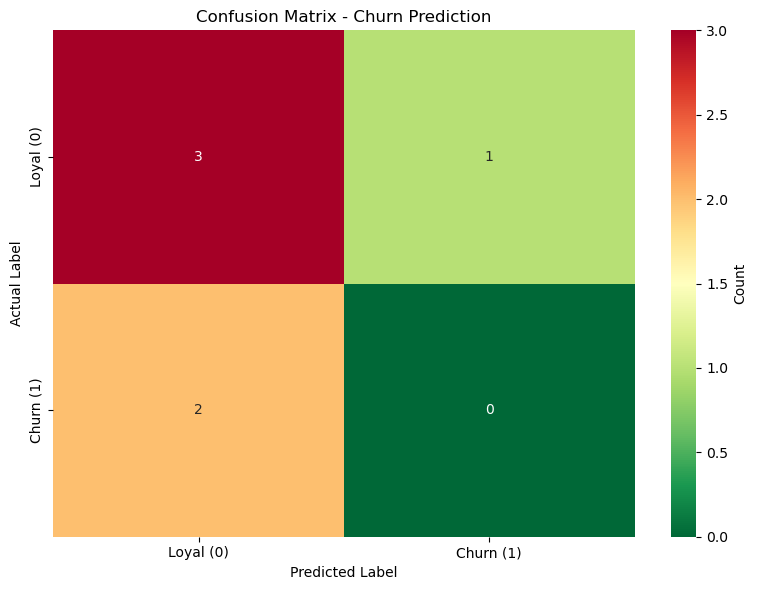


✅ Overall Accuracy: 50.0%


In [7]:
print("📊 === CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Loyal (0)', 'Churn (1)']))

# Visualizing the Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='RdYlGn_r',
    xticklabels=['Loyal (0)', 'Churn (1)'],
    yticklabels=['Loyal (0)', 'Churn (1)'],
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Churn Prediction')
plt.tight_layout()
plt.show()

accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()
print(f"\n✅ Overall Accuracy: {accuracy:.1%}")

## Step 8: Feature Importance Analysis

Which features are most predictive of churn? This helps us understand the key drivers.

🎯 Feature Importance:
   Feature  Importance
  monetary    0.331604
avg_ticket    0.307129
   recency    0.302255
 frequency    0.059013


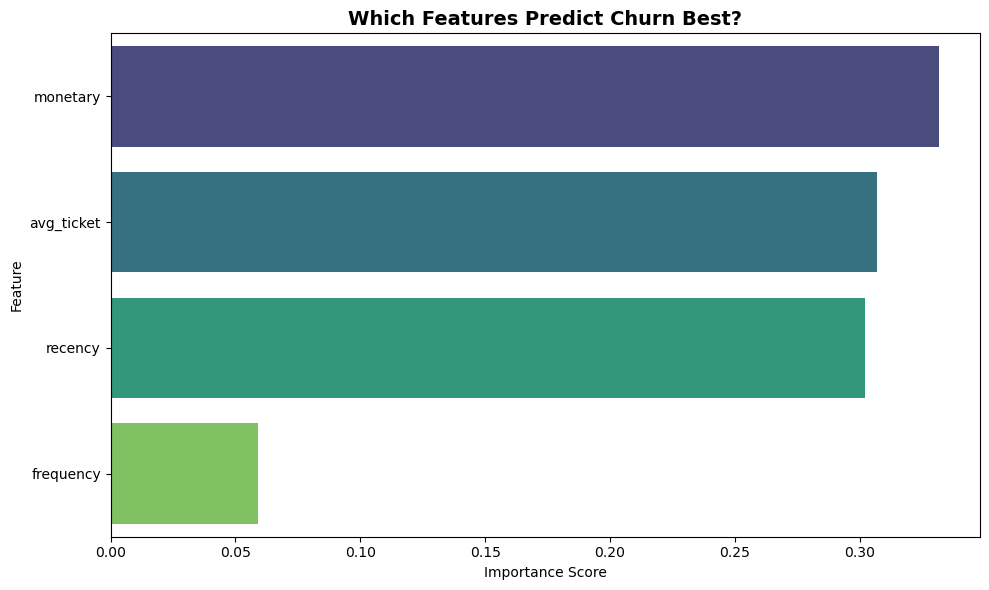

In [8]:
# 1. Get feature importance from the trained model
importances = model.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("🎯 Feature Importance:")
print(feature_importance_df.to_string(index=False))

# 3. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='viridis',
    hue='Feature',
    legend=False
)
plt.title('Which Features Predict Churn Best?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 9: Make Predictions on New Customers

Example predictions for different customer profiles:
- **Inactive Customer**: High recency, low frequency → High churn risk
- **Active Customer**: Low recency, high frequency → Low churn risk

In [9]:
print("🔮 MAKING PREDICTIONS ON NEW CUSTOMERS\n")
print("="*70)

# Example 1: Inactive customer
new_customer_1 = pd.DataFrame(
    [[45, 1, 50, 50]], 
    columns=['recency', 'frequency', 'monetary', 'avg_ticket']
)
new_customer_1_scaled = scaler.transform(new_customer_1)
prob_1 = model.predict_proba(new_customer_1_scaled)[0][1]

print(f"\n📌 CUSTOMER 1 (Inactive):")
print(f"   Recency: 45 days  |  Frequency: 1 order  |  Monetary: $50")
print(f"   Churn Probability: {prob_1:.1%}")
if prob_1 > 0.7:
    print(f"   ⚠️  HIGH RISK - Action: Send 'We Miss You' discount")
elif prob_1 > 0.4:
    print(f"   🟡 MEDIUM RISK - Action: Send nurture email")
else:
    print(f"   ✅ LOW RISK - Action: Standard newsletter")

print("\n" + "="*70)

# Example 2: Active customer
new_customer_2 = pd.DataFrame(
    [[5, 5, 500, 100]], 
    columns=['recency', 'frequency', 'monetary', 'avg_ticket']
)
new_customer_2_scaled = scaler.transform(new_customer_2)
prob_2 = model.predict_proba(new_customer_2_scaled)[0][1]

print(f"\n📌 CUSTOMER 2 (Active):")
print(f"   Recency: 5 days  |  Frequency: 5 orders  |  Monetary: $500")
print(f"   Churn Probability: {prob_2:.1%}")
if prob_2 > 0.7:
    print(f"   ⚠️  HIGH RISK - Action: Send 'We Miss You' discount")
elif prob_2 > 0.4:
    print(f"   🟡 MEDIUM RISK - Action: Send nurture email")
else:
    print(f"   ✅ LOW RISK - Action: Standard newsletter")

print("\n" + "="*70)

🔮 MAKING PREDICTIONS ON NEW CUSTOMERS


📌 CUSTOMER 1 (Inactive):
   Recency: 45 days  |  Frequency: 1 order  |  Monetary: $50
   Churn Probability: 35.1%
   ✅ LOW RISK - Action: Standard newsletter


📌 CUSTOMER 2 (Active):
   Recency: 5 days  |  Frequency: 5 orders  |  Monetary: $500
   Churn Probability: 45.2%
   🟡 MEDIUM RISK - Action: Send nurture email



## Step 10: Save Model & Scaler

Export trained model and scaler for deployment.

In [10]:
import joblib

# 1. Save the model to a file
joblib.dump(model, 'churn_model.pkl')

# 2. Save the scaler to a file
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model and Scaler saved as .pkl files!")
print("\nFiles created:")
print("  - churn_model.pkl")
print("  - scaler.pkl")

✅ Model and Scaler saved as .pkl files!

Files created:
  - churn_model.pkl
  - scaler.pkl


## Step 11: Load & Reuse Model

Here's how to load the model in a different script or notebook.

In [11]:
# How to load and use the model in a different file:
loaded_model = joblib.load('churn_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

def predict_customer_vibe(r, f, m):
    """
    Predict churn risk for a customer given Recency, Frequency, Monetary.
    
    Args:
        r: Recency (days since last purchase)
        f: Frequency (total number of orders)
        m: Monetary (total spending)
    
    Returns:
        str: Status message (Churn Risk or Loyal)
    """
    avg_t = m / f
    input_data = pd.DataFrame(
        [[r, f, m, avg_t]], 
        columns=['recency', 'frequency', 'monetary', 'avg_ticket']
    )
    
    # Scale and Predict
    scaled_input = loaded_scaler.transform(input_data)
    probability = loaded_model.predict_proba(scaled_input)[0][1]
    
    if probability > 0.7:
        return f"⚠️  HIGH CHURN RISK ({probability:.1%})"
    elif probability > 0.4:
        return f"🟡 MEDIUM CHURN RISK ({probability:.1%})"
    else:
        return f"✅ LOYAL CUSTOMER ({probability:.1%} risk)"

print("\n🧪 Testing the predict_customer_vibe() function:\n")
print(f"Customer 1 (inactive):  {predict_customer_vibe(40, 1, 100)}")
print(f"Customer 2 (regular):   {predict_customer_vibe(15, 3, 300)}")
print(f"Customer 3 (active):    {predict_customer_vibe(5, 5, 500)}")


🧪 Testing the predict_customer_vibe() function:

Customer 1 (inactive):  🟡 MEDIUM CHURN RISK (60.6%)
Customer 2 (regular):   ⚠️  HIGH CHURN RISK (74.7%)
Customer 3 (active):    🟡 MEDIUM CHURN RISK (45.2%)


## Step 12: Deploy as Streamlit App

Create an interactive web interface for real-time predictions.

In [12]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np
import pandas as pd

# 1. Load the saved model and scaler
model = joblib.load('churn_model.pkl')
scaler = joblib.load('scaler.pkl')

# 2. Set up the UI
st.set_page_config(page_title="Churn Predictor", page_icon="📊", layout="wide")
st.title("📊 E-Commerce Churn Predictor")
st.markdown("Enter customer details below to predict the probability of churn.")
st.markdown("---")

# 3. Create Input Sliders
col1, col2, col3 = st.columns(3)

with col1:
    recency = st.slider("📅 Recency (Days since last purchase)", 0, 90, 20)

with col2:
    frequency = st.number_input("🛍️  Frequency (Total Orders)", min_value=1, max_value=50, value=3)

with col3:
    monetary = st.number_input("💰 Monetary (Total Spend $)", min_value=10.0, max_value=5000.0, value=300.0)

# 4. Prediction Button
if st.button("🔮 Predict Churn Risk", key="predict_btn"):
    try:
        avg_ticket = monetary / frequency

        # Create DataFrame with proper column names
        features = pd.DataFrame(
            [[recency, frequency, monetary, avg_ticket]],
            columns=["recency", "frequency", "monetary", "avg_ticket"]
        )

        # Scale and Predict
        features_scaled = scaler.transform(features)
        prob = model.predict_proba(features_scaled)[0][1]
        prediction = model.predict(features_scaled)[0]

        # Display Result with rich formatting
        st.markdown("---")
        st.subheader(f"Churn Probability: {prob:.1%}")
        
        if prob > 0.7:
            st.error(f"🚨 **HIGH RISK**: This customer is very likely to churn ({prob:.1%})")
            st.info("💡 **Recommended Action**: Send exclusive discount or re-engagement offer immediately")
        elif prob > 0.4:
            st.warning(f"🟡 **MEDIUM RISK**: This customer shows signs of disengagement ({prob:.1%})")
            st.info("💡 **Recommended Action**: Send personalized follow-up email or special offer")
        else:
            st.success(f"✅ **LOW RISK**: This is a loyal customer ({prob:.1%} churn risk)")
            st.info("💡 **Recommended Action**: Continue with standard loyalty program")
        
        # Display customer profile
        st.markdown("---")
        st.subheader("📋 Customer Profile")
        col1, col2, col3, col4 = st.columns(4)
        col1.metric("Recency", f"{recency} days")
        col2.metric("Frequency", f"{frequency} orders")
        col3.metric("Monetary", f"${monetary:.2f}")
        col4.metric("Avg Ticket", f"${avg_ticket:.2f}")
        
    except Exception as e:
        st.error(f"Error: {str(e)}")

st.markdown("---")
st.markdown("""
### 📚 How It Works:
- **Recency**: How long it's been since the customer made a purchase
- **Frequency**: Total number of purchases by the customer
- **Monetary**: Total amount spent by the customer
- The model uses Random Forest to predict churn probability based on these RFM metrics
""")

Overwriting app.py


## Step 13: Launch Streamlit App

Run the app using the command below.

In [13]:
# ✅ Run this cell to launch the Streamlit app in your terminal
# After running, open: http://localhost:8501

import subprocess, sys
print("🚀 To launch the Streamlit app, run this command in your terminal:")
print()
print("    streamlit run app.py")
print()
print("Then open http://localhost:8501 in your browser")
print()
print("="*70)

🚀 To launch the Streamlit app, run this command in your terminal:

    streamlit run app.py

Then open http://localhost:8501 in your browser



In [14]:
# Optional: Uncomment and run to start Streamlit directly from notebook
import subprocess
subprocess.Popen(["streamlit", "run", "app.py"])
print("✅ Streamlit app launched! Open http://localhost:8501 in your browser.")

✅ Streamlit app launched! Open http://localhost:8501 in your browser.
